In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### LOAD DATASET

In [5]:
df = pd.read_csv(r"..\data\income_random_forest.csv")

print(df.head())
print(df.info())
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             120 non-null    int64
 1   EducationYears  120 non-null    int64
 2   HoursPerWeek    120 non-null    int64
 3   Experience      120 non-null    int64
 4   Income          120 non-null    int64
dtypes: int64(5)
memory usage: 4.8 KB
None
              Age  EducationYears  HoursPerWeek  Experience      Income
count  120.000000      120.000000    120.000000  120.000000  120.000000
mean    40.725000       13.575000     40.641667   20.333333    0.333333
std  

### FEATURES AND TARGET

In [6]:
feature_names = ['Age', 'EducationYears', 'HoursPerWeek', 'Experience']

X = df[feature_names]
y = df['Income']

print("Target Distribution:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Target Distribution:
 Income
0    80
1    40
Name: count, dtype: int64


### HYPERPARAMETER TUNNING

In [7]:
tree_range   = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]
train_scores = []
test_scores  = []

for n in tree_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    train_scores.append(accuracy_score(y_train, rf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))

best_n = tree_range[np.argmax(test_scores)]
print("Best n_estimators:", best_n)

Best n_estimators: 10


### TRAIN MODEl

In [8]:
rf_best = RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)

y_pred = rf_best.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00        16
        >50K       1.00      1.00      1.00         8

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


Confusion Matrix:
 [[16  0]
 [ 0  8]]


### VISUALIZATION

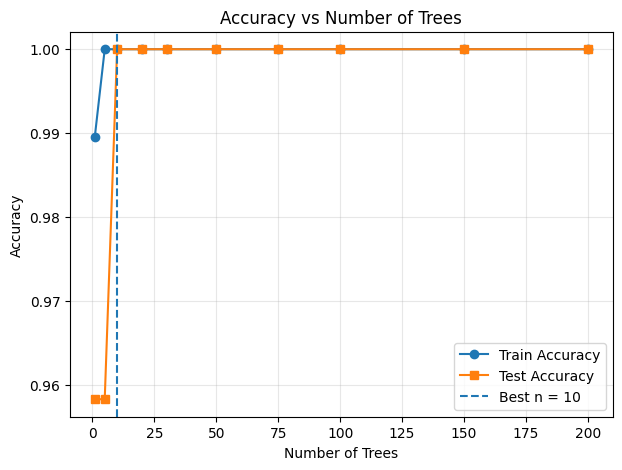

In [9]:
plt.figure(figsize=(7, 5))

plt.plot(tree_range, train_scores, marker='o', label='Train Accuracy')
plt.plot(tree_range, test_scores, marker='s', label='Test Accuracy')

plt.axvline(best_n, linestyle='--', label=f'Best n = {best_n}')

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

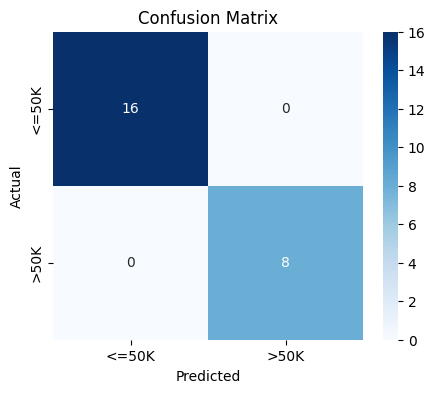

In [ ]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["<=50K", ">50K"],
            yticklabels=["<=50K", ">50K"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

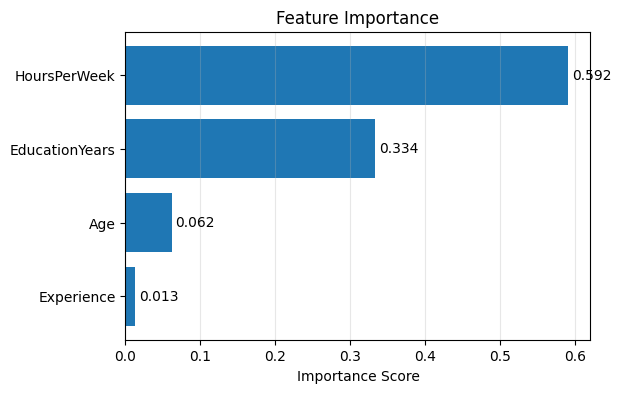

In [12]:
importances = rf_best.feature_importances_

idx = np.argsort(importances)
sorted_idx = idx[np.argsort(importances[idx])]

plt.figure(figsize=(6, 4))

plt.barh([feature_names[i] for i in sorted_idx],
         importances[sorted_idx])

for i, v in enumerate(importances[sorted_idx]):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center')

plt.xlabel("Importance Score")
plt.title("Feature Importance")

plt.grid(axis='x', alpha=0.3)

plt.show()